<a href="https://colab.research.google.com/github/updalla-apshir/machine-learning-projects/blob/main/Building_Logistic_Regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression

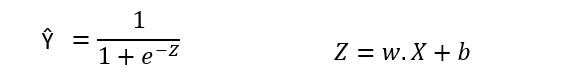

Y_hat --> predicted value

X --> Input Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

**Derivatives:**

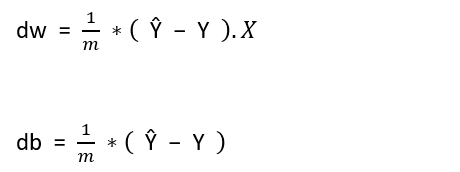

Importing the Dependencies

In [ ]:
import numpy as np

In [ ]:
class LogisticRegression():

    # set hyperparameters
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations


    def fit(self, X, Y):

        self.m, self.n = X.shape

        # initialize weights and bias
        self.w = np.zeros(self.n)
        self.b = 0

        self.X = X
        self.Y = Y

        # Gradient Descent
        for i in range(self.no_of_iterations):
            self.update_weights()


    def update_weights(self):

        # sigmoid function
        Y_cap = 1 / (1 + np.exp(-(self.X.dot(self.w) + self.b)))

        # derivatives
        dw = (1 / self.m) * np.dot(self.X.T, (Y_cap - self.Y))
        db = (1 / self.m) * np.sum(Y_cap - self.Y)

        # update parameters
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db


    def predict(self, X):

        Y_pred = 1 / (1 + np.exp(-(X.dot(self.w) + self.b)))

        Y_pred = np.where(Y_pred > 0.5, 1, 0)

        return Y_pred

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

Data Preprocessing

In [ ]:
diabetes = fetch_openml('diabetes')


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name diabetes exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=37
- version 5, status: active
  url: https://www.openml.org/search?type=data&id=42608

  warn(warning_msg)


In [ ]:
diabetes_df = pd.DataFrame(diabetes.data,columns=diabetes.feature_names)

In [ ]:
diabetes_df

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
# checking duplicates
diabetes_df.isnull().sum()

,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0


In [ ]:
# checking duplicate
diabetes_df.duplicated().sum()

np.int64(0)

In [ ]:
X = diabetes.data
Y = diabetes.target

In [ ]:
Y.value_counts()

,count
class,
tested_negative,500
tested_positive,268


In [ ]:
# split into training and testing
X_train, X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
# load the label encoder function
label_encode = LabelEncoder()

In [ ]:
label_encode.fit(Y_train)

LabelEncoder()

In [ ]:
Y_train = label_encode.transform(Y_train)

In [ ]:
Y_test = label_encode.transform(Y_test)

In [ ]:
# feature scaling
scaler = StandardScaler()

In [ ]:
# feed into training data
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Train Our LogisticRegression Model

In [ ]:
model = LogisticRegression(learning_rate=0.01, no_of_iterations=1000)


In [ ]:
model.fit(X_train,Y_train)

In [ ]:
train_pred = model.predict(X_train)

In [ ]:
training_accuracy = accuracy_score(Y_train,train_pred)

In [ ]:
print('training accuracy: ', training_accuracy)

training accuracy:  0.7719869706840391


In [ ]:
# predict testing data
test_pred = model.predict(X_test)

In [ ]:
test_accuracy = accuracy_score(Y_test,test_pred)

In [ ]:
print('testing accuracy: ', test_accuracy)

testing accuracy:  0.7662337662337663


## Making a Predictive System

In [ ]:
input = (6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0)

input_as_array = np.array(input)
input_reshaped = input_as_array.reshape(1,-1)

standrized_input = scaler.transform(input_reshaped)

prediction = model.predict(standrized_input)

if prediction[0] == 1:
    print('The person is diabetic')
else:
    print('The person is not diabetic')

The person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Printing the input data and actual value to test whether it predicted

In [ ]:
values = X.iloc[48]
print(','.join(map(str,values)))

7.0,103.0,66.0,32.0,0.0,39.1,0.344,31.0


In [ ]:
Y.iloc[48]

'tested_negative'